## Exporting quality control for exploring and plotting in R

Load library

In [1]:
# Path-related libraries
import os
from pyhere import here  # For reproducible relative paths
import sys # system specific parameters
from pathlib import Path # File system paths

# AnnData and single-cell analysis libraries
import scanpy as sc       # For preprocessing and visualization of single-cell data
import anndata as ad      # For handling AnnData objects

# Numerical operations
import numpy as np        # For numerical computations and array manipulations
import pandas as pd

# Plotting 
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Diff genes
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data

# Custom modules and functions
sys.path.append(str(here('scripts/misc')))  # Add custom script path to system
import my_anndata as ma                    # Custom AnnData utilities

Parameters

In [2]:
# save paths
base_dir = str(here('data/integrate/second_pass/'))
plot_dir = os.path.join(base_dir, 'plot') 
files_dir = os.path.join(base_dir, 'files') 
objects_dir = os.path.join(base_dir, 'objects') 
tmp_dir = os.path.join(base_dir, 'tmp') 

Get info from ncbi about genes

In [3]:
# # Download gene info text from genes from ncbi (acess: 06-11-2025)
# !wget https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Mammalia/Homo_sapiens.gene_info.gz
# !gunzip Homo_sapiens.gene_info.gz
# # Download gene summary text from genes from ncbi (acess: 06-11-2025)
# !wget https://ftp.ncbi.nlm.nih.gov/gene/DATA/gene_summary.gz

# load summaries
gene_summary = pd.read_csv( "gene_summary.gz", sep="\t", dtype=str)
homo_gene = pd.read_csv( "Homo_sapiens.gene_info", sep="\t", dtype=str)

# map of ncbi gene id to symbol
homo_gene_map = homo_gene.set_index('GeneID')['Symbol'].to_dict()

# subset gene is to human taxid (9606), and add gene symbols
gene_summary=gene_summary[gene_summary['#tax_id']=='9606']

# Add synbol to gene id
gene_summary['symbol'] = gene_summary['GeneID'].map(homo_gene_map)

Import data

In [4]:
# AnnData object
adata = ad.read_h5ad(os.path.join(objects_dir, 'AB_adata_full_with_latent.h5ad'))
doublet_probs = pd.read_csv(os.path.join(files_dir, 'doublet_probabilities.csv'), index_col= 'barcode')
module_score = pd.read_csv(os.path.join(files_dir, 'marker_gene_scores.csv'), index_col= 0)
module_score = module_score [[column for column in module_score.columns if column.startswith('azimuth')]]

Combine adata obs with doublet probabilities and module scores, and save as csv

In [5]:
adata.obs = adata.obs.join(
    doublet_probs[["doublet_probability"]],
    how="left")
adata.obs = adata.obs.join(module_score)

Load dds object

In [6]:
import pickle as pkl
with open(os.path.join(tmp_dir, "dds.pkl"), "rb") as f:
    dds = pkl.load(f)

Diffential expressed genes

In [ ]:
# add platform adjusted sample id
adata.obs['ic_id_platform_adjusted_sample'] = np.where(
    adata.obs['platform'].isin(['droplet', 'plate_barcode']),
    adata.obs['ic_id_sample'],
    np.where(adata.obs['platform'].isin(['plate']),
             adata.obs['ic_id_dataset_donor'],
             None)  # optional: fallback if platform is something else
)

# Add seperation
clusters =  ["53",  "75", "176"]
adata.obs['cluster_vs_other'] = np.where(
    adata.obs['leiden_res_10.00'].isin(clusters),  # condition
    adata.obs['leiden_res_10.00'],                # value if True
    'other'                                       # value if False
)

pseudobulk_adata = sc.get.aggregate(adata = adata,
                           by = ['ic_id_platform_adjusted_sample', 'cluster_vs_other'], layer = 'counts', func = 'sum')

# Extract counts from layers['sum']
counts_df = pd.DataFrame(pseudobulk_adata.layers['sum'], columns=pseudobulk_adata.var_names, index=pseudobulk_adata.obs_names)

# Metadata / covariates
metadata_df = pseudobulk_adata.obs[['cluster_vs_other', 'ic_id_platform_adjusted_sample']].copy()

# Filter data
# Filter out genes that have less than 10 read counts in total.
genes_to_keep = counts_df.columns[counts_df.sum(axis=0) >= 10]
counts_df = counts_df[genes_to_keep]

# Create Deseq object
inference = DefaultInference(n_cpus=30)

dds = DeseqDataSet(
    counts=counts_df,
    metadata=metadata_df,
    design="~ ic_id_platform_adjusted_sample + cluster_vs_other", 
    refit_cooks=True,
    inference=inference,
)

# Fit dispertion and logfoldchanges
dds.deseq2()


In [ ]:
import pickle as pkl
with open(os.path.join(tmp_dir, "dds.pkl"), "wb") as f:
    pkl.dump(dds, f)

Cluster 53

In [ ]:
# Statistical test
ds = DeseqStats(
    dds,
    contrast=("cluster_vs_other", "53", "other"), 
    inference = inference)

# run wald test
ds.run_wald_test()

In [ ]:
# Extract results, calculate % of cells that express this gene in target cluster
res_53 = ds.results_df.copy()

cluster = "53"
subset = adata[adata.obs["leiden_res_10.00"] == cluster]

# Extract the raw counts layer as a matrix
X = subset.layers['counts']

# Handle sparse matrix efficiently
if hasattr(X, "toarray"):
    X = X.toarray()

# Compute % of cells expressing each gene (vectorized)
pct_expr = (X > 0).sum(axis=0) / X.shape[0] * 100

# Convert to Series with gene names
pct_expr = pd.Series(np.round(pct_expr, decimals= 2), index=subset.var_names, name=f"pct_expr_cluster_{cluster}")

# Merge with filtered DE results
res_53 = res_53.merge(pct_expr, left_index=True, right_index=True, how="left")

In [ ]:
# Add gene summary to results
# subset to only contain tested genes
gene_summary_sub=gene_summary[gene_summary['symbol'].isin(list(res_53.index))]

# create subset that only contains symbol and summary
gene_summary_sub = gene_summary_sub[['symbol', 'Summary']]
gene_summary_sub = gene_summary_sub.set_index('symbol')

# add summary to res
res_53 = res_53.merge(testsub, left_index=True, right_index=True, how="left")

# save
res_53.to_csv(os.path.join(files_dir, 'diff_genes_53.csv'), index_label='barcode')

In [ ]:
filtered_53 = res_53[(res_53.padj <= 0.05) & (res_53.log2FoldChange >= 0) & (res_53.pct_expr_cluster_53 >= 50)]
top20_53 = filtered_53.sort_values(by=['padj', 'log2FoldChange'], ascending=[True, False]).head(20)
top20_53.to_csv(os.path.join(files_dir, 'diff_genes_53_top20.csv'), index_label='barcode')

Cluster 75

In [ ]:
# Statistical test
ds = DeseqStats(
    dds,
    contrast=("cluster_vs_other", "75", "other"), 
    inference = inference)

# run wald test
ds.run_wald_test()

# summary
ds.summary()

# Extract results, calculate % of cells that express this gene in target cluster
res_75 = ds.results_df.copy()

cluster = "75"
subset = adata[adata.obs["leiden_res_10.00"] == cluster]

# Extract the raw counts layer as a matrix
X = subset.layers['counts']

# Handle sparse matrix efficiently
if hasattr(X, "toarray"):
    X = X.toarray()

# Compute % of cells expressing each gene (vectorized)
pct_expr = (X > 0).sum(axis=0) / X.shape[0] * 100

# Convert to Series with gene names
pct_expr = pd.Series(np.round(pct_expr, decimals= 2), index=subset.var_names, name=f"pct_expr_cluster_{cluster}")

# Merge with filtered DE results
res_75 = res_75.merge(pct_expr, left_index=True, right_index=True, how="left")

# Add gene summary to results
# subset to only contain tested genes
gene_summary_sub=gene_summary[gene_summary['symbol'].isin(list(res_75.index))]

# create subset that only contains symbol and summary
gene_summary_sub = gene_summary_sub[['symbol', 'Summary']]
gene_summary_sub = gene_summary_sub.set_index('symbol')

# add summary to res
res_75 = res_75.merge(testsub, left_index=True, right_index=True, how="left")

# save
res_75.to_csv(os.path.join(files_dir, 'diff_genes_75.csv'), index_label='barcode')

filtered_75 = res_75[(res_75.padj <= 0.05) & (res_75.log2FoldChange >= 0) & (res_75.pct_expr_cluster_75 >= 50)]
top20_75 = filtered_75.sort_values(by=['padj', 'log2FoldChange'], ascending=[True, False]).head(20)
top20_75.to_csv(os.path.join(files_dir, 'diff_genes_75_top20.csv'), index_label='barcode')

Cluster 176

In [ ]:
# Statistical test
ds = DeseqStats(
    dds,
    contrast=("cluster_vs_other", "176", "other"), 
    inference = inference)

# run wald test
ds.run_wald_test()

# summary
ds.summary()

# Extract results, calculate % of cells that express this gene in target cluster
res_176 = ds.results_df.copy()

cluster = "176"
subset = adata[adata.obs["leiden_res_10.00"] == cluster]

# Extract the raw counts layer as a matrix
X = subset.layers['counts']

# Handle sparse matrix efficiently
if hasattr(X, "toarray"):
    X = X.toarray()

# Compute % of cells expressing each gene (vectorized)
pct_expr = (X > 0).sum(axis=0) / X.shape[0] * 100

# Convert to Series with gene names
pct_expr = pd.Series(np.round(pct_expr, decimals= 2), index=subset.var_names, name=f"pct_expr_cluster_{cluster}")

# Merge with filtered DE results
res_176 = res_176.merge(pct_expr, left_index=True, right_index=True, how="left")

# Add gene summary to results
# subset to only contain tested genes
gene_summary_sub=gene_summary[gene_summary['symbol'].isin(list(res_176.index))]

# create subset that only contains symbol and summary
gene_summary_sub = gene_summary_sub[['symbol', 'Summary']]
gene_summary_sub = gene_summary_sub.set_index('symbol')

# add summary to res
res_176 = res_176.merge(testsub, left_index=True, right_index=True, how="left")

# save
res_176.to_csv(os.path.join(files_dir, 'diff_genes_176.csv'), index_label='barcode')

filtered_176 = res_176[(res_176.padj <= 0.05) & (res_176.log2FoldChange >= 0) & (res_176.pct_expr_cluster_176 >= 50)]
top20_176 = filtered_176.sort_values(by=['padj', 'log2FoldChange'], ascending=[True, False]).head(20)
top20_176.to_csv(os.path.join(files_dir, 'diff_genes_176_top20.csv'), index_label='barcode')

In [ ]:
# # Download gene ontology sources:
# !wget https://current.geneontology.org/ontology/go-basic.obo
# !wget https://current.geneontology.org/annotations/goa_human.gaf.gz
# !gunzip goa_human.gaf.gz

from goatools.obo_parser import GODag
from goatools.associations import read_gaf
import pandas as pd
from mygene import MyGeneInfo
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# ------------------------------------------
# Load GO DAG and GAF annotations
# ------------------------------------------
obo = GODag("go-basic.obo")
gaf = read_gaf("goa_human.gaf")   # dict: GO term -> set of gene IDs (Entrez/UniProt depending on source)

# GAF is dict: {uniprot_id: {GO_term1, GO_term2, ...}}
print(f"Loaded {len(gaf)} gene-GO associations")

# ------------------------------------------
# Map UniProt IDs → Entrez IDs
# ------------------------------------------
mg = MyGeneInfo()

# Extract all uniprot genes, that are found in go-terms
uniprot_ids = list(gaf.keys())

# Query mygene.info API to map UniProt → Entrez
mapping = mg.querymany(uniprot_ids, scopes="uniprot", fields="entrezgene", species="human")

# Make a mapping dictionary with uniprot x entrez genes
uni_to_entrez = {m["query"]: str(m["entrezgene"]) for m in mapping if "entrezgene" in m}

# Make a mapping dictionary with eniprot x gene symbols 
mapping = mg.querymany(uniprot_ids, scopes="uniprot", fields="symbol", species="human")
uni_to_symbol = {m["query"]: str(m["symbol"]) for m in mapping if "symbol" in m}

# Filter GAF annotations to those with Entrez mappings
rows = []
for uni, go_terms in gaf.items():
    if uni not in uni_to_entrez:
        continue
    entrez = uni_to_entrez[uni]
    symbol = uni_to_symbol[uni]
    
    for go in go_terms:
        rows.append((entrez, symbol, go))

# Make a dataframe, with go terms, entrez id, and their name
go_df = pd.DataFrame(rows, columns=["entrez", "symbol", "GO_term"])
go_df["GO_name"] = go_df["GO_term"].map(lambda go: obo[go].name if go in obo else None)
go_df["GO_space"] = go_df["GO_term"].map(lambda go: obo[go].namespace if go in obo else None)

print(f"GO annotations available for {go_df['entrez'].nunique()} Entrez genes")

GO-term analysis

In [ ]:
# Define universe
genes =pd.read_csv(here('genome_files/gene_entrez_map.csv'), index_col = 1, dtype='str')
# create dictionary
gene_map = genes['entrez_id'].to_dict()

# add entrez id to index
res_53['entrez_id'] = res_53.index.map(gene_map)

# Genes up interest (upregulated in cluster 53)
filtered_53 = res_53[(res_53.padj <= 0.05) & (res_53.log2FoldChange >= 0) & (res_53.pct_expr_cluster_53 >= 50)]

# genes upregulated in target
genes_to_test = filtered_53['entrez_id'].dropna().tolist()

# universe
universe = res_53['entrez_id'].dropna().tolist()
# https://geneontology.org/docs/download-ontology/

# https://bioinformatics.ccr.cancer.gov/docs/btep-coding-club/CC2023/FunctionalEnrich_clusterProfiler/

# Filter annotations to universe only
go_df_test = go_df[go_df["entrez"].isin(universe)]
    
universe = set(universe)
genes_to_test = set(genes_to_test)

# Prepare results
results = []
for go_term, group in go_df_test.groupby("GO_term"):
    genes_in_term = set(group["entrez"])
    a = len(genes_to_test & genes_in_term) # genes in test set and go terms
    b = len(genes_to_test - genes_in_term) # genes in test but not in go terms
    c = len((universe & genes_in_term) - genes_to_test) # background genes that are not in test, that are in go terms
    d = len(universe - genes_in_term - genes_to_test) # background genes that are not in test and not in go terms

    # if non of the test or background genes are found in the go term, skip
    if a + c == 0:
        continue

    odds, p = fisher_exact([[a, b], [c, d]], alternative="greater")

    # Create a list of genes in test set that are in go terms
    genes_in_term = set(group["entrez"])
    overlap = genes_to_test & genes_in_term
    df=group[group["entrez"].isin(overlap)]
    gene_symbols=df['symbol'].tolist()
    
    results.append({
        "go_term": go_term,
        "go_name": obo[go_term].name if go_term in obo else None,
        "gene_id": ','.join(map(str, gene_symbols)),
        "gene_ratio": f'{a}/{len(genes_to_test)}', #ratio of input genes that are annotated in a term
        "gene_ratio_term": f'{a}/{len(genes_in_term)}',
        "bg_ratio": f'{c}/{len(universe)}', # ratio of all genes that are annotated in this term
        "odds_ratio": odds, "pval": p
    })

res_go = pd.DataFrame(results)
res_go["p_adj"] = multipletests(res_go["pval"], method="fdr_bh")[1]
res_go  = res_go.sort_values("p_adj").reset_index(drop=True)

res_go[(res_go.p_adj <= 0.05)]

In [ ]:
# Define universe
genes =pd.read_csv(here('genome_files/gene_entrez_map.csv'), index_col = 1, dtype='str')
# create dictionary
gene_map = genes['entrez_id'].to_dict()

# add entrez id to index
res_176['entrez_id'] = res_176.index.map(gene_map)

# Genes up interest (upregulated in cluster 176)
filtered_176 = res_176[(res_176.padj <= 0.05) & (res_176.log2FoldChange >= 0) & (res_176.pct_expr_cluster_176 >= 50)]

# genes upregulated in target
genes_to_test = filtered_176['entrez_id'].dropna().tolist()

# universe
universe = res_176['entrez_id'].dropna().tolist()
# https://geneontology.org/docs/download-ontology/

# https://bioinformatics.ccr.cancer.gov/docs/btep-coding-club/CC2023/FunctionalEnrich_clusterProfiler/

# Filter annotations to universe only
go_df_test = go_df[go_df["entrez"].isin(universe)]
    
universe = set(universe)
genes_to_test = set(genes_to_test)

# Prepare results
results = []
for go_term, group in go_df_test.groupby("GO_term"):
    genes_in_term = set(group["entrez"])
    a = len(genes_to_test & genes_in_term) # genes in test set and go terms
    b = len(genes_to_test - genes_in_term) # genes in test but not in go terms
    c = len((universe & genes_in_term) - genes_to_test) # background genes that are not in test, that are in go terms
    d = len(universe - genes_in_term - genes_to_test) # background genes that are not in test and not in go terms

    # if non of the test or background genes are found in the go term, skip
    if a + c == 0:
        continue

    odds, p = fisher_exact([[a, b], [c, d]], alternative="greater")

    # Create a list of genes in test set that are in go terms
    genes_in_term = set(group["entrez"])
    overlap = genes_to_test & genes_in_term
    df=group[group["entrez"].isin(overlap)]
    gene_symbols=df['symbol'].tolist()
    
    results.append({
        "go_term": go_term,
        "go_name": obo[go_term].name if go_term in obo else None,
        "gene_id": ','.join(map(str, gene_symbols)),
        "gene_ratio": f'{a}/{len(genes_to_test)}', #ratio of input genes that are annotated in a term
        "gene_ratio_term": f'{a}/{len(genes_in_term)}',
        "bg_ratio": f'{c}/{len(universe)}', # ratio of all genes that are annotated in this term
        "odds_ratio": odds, "pval": p
    })

res_go = pd.DataFrame(results)
res_go["p_adj"] = multipletests(res_go["pval"], method="fdr_bh")[1]
res_go  = res_go.sort_values("p_adj").reset_index(drop=True)

res_go[(res_go.p_adj <= 0.05)]

In [ ]:
# Define universe
genes =pd.read_csv(here('genome_files/gene_entrez_map.csv'), index_col = 1, dtype='str')
# create dictionary
gene_map = genes['entrez_id'].to_dict()

# add entrez id to index
res_75['entrez_id'] = res_75.index.map(gene_map)

# Genes up interest (upregulated in cluster 75)
filtered_75 = res_75[(res_75.padj <= 0.05) & (res_75.log2FoldChange >= 0) & (res_75.pct_expr_cluster_75 >= 50)]

# genes upregulated in target
genes_to_test = filtered_75['entrez_id'].dropna().tolist()

# universe
universe = res_75['entrez_id'].dropna().tolist()
# https://geneontology.org/docs/download-ontology/

# https://bioinformatics.ccr.cancer.gov/docs/btep-coding-club/CC2023/FunctionalEnrich_clusterProfiler/

# Filter annotations to universe only
go_df_test = go_df[go_df["entrez"].isin(universe)]
    
universe = set(universe)
genes_to_test = set(genes_to_test)

# Prepare results
results = []
for go_term, group in go_df_test.groupby("GO_term"):
    genes_in_term = set(group["entrez"])
    a = len(genes_to_test & genes_in_term) # genes in test set and go terms
    b = len(genes_to_test - genes_in_term) # genes in test but not in go terms
    c = len((universe & genes_in_term) - genes_to_test) # background genes that are not in test, that are in go terms
    d = len(universe - genes_in_term - genes_to_test) # background genes that are not in test and not in go terms

    # if non of the test or background genes are found in the go term, skip
    if a + c == 0:
        continue

    odds, p = fisher_exact([[a, b], [c, d]], alternative="greater")

    # Create a list of genes in test set that are in go terms
    genes_in_term = set(group["entrez"])
    overlap = genes_to_test & genes_in_term
    df=group[group["entrez"].isin(overlap)]
    gene_symbols=df['symbol'].tolist()
    
    results.append({
        "go_term": go_term,
        "go_name": obo[go_term].name if go_term in obo else None,
        "gene_id": ','.join(map(str, gene_symbols)),
        "gene_ratio": f'{a}/{len(genes_to_test)}', #ratio of input genes that are annotated in a term
        "gene_ratio_term": f'{a}/{len(genes_in_term)}',
        "bg_ratio": f'{c}/{len(universe)}', # ratio of all genes that are annotated in this term
        "odds_ratio": odds, "pval": p
    })

res_go = pd.DataFrame(results)
res_go["p_adj"] = multipletests(res_go["pval"], method="fdr_bh")[1]
res_go  = res_go.sort_values("p_adj").reset_index(drop=True)

res_go[(res_go.p_adj <= 0.05)]

In [ ]:
sc.set_figure_params(figsize=(3, 3), frameon=False, dpi_save= 300)
cluster = "176"
subset = adata[adata.obs["leiden_res_10.00"] == cluster]
sc.pl.embedding(
    subset, 
    basis="X_latent_2_umap", 
    color=list(top20_176.index)+['doublet_probability'], 
    size = 5, 
    ncols = 7,
    frameon=False
)

In [ ]:
sc.set_figure_params(figsize=(10, 10), frameon=False, dpi_save= 300)
sc.pl.embedding(
    adata, 
    basis="X_latent_2_umap", 
    color=['Y_RNA_386'], 
    size = 1,
    frameon=False
)

Get normalized counts

In [9]:
normalized_counts=pd.DataFrame(dds.layers['normed_counts'], columns=dds.var_names, index=dds.obs_names)

In [11]:
normalized_counts = normalized_counts.merge(metadata_df, left_index=True, right_index=True, how="left")

In [17]:
normalized_counts = normalized_counts.merge(adata.obs.reset_index()[['ic_id_platform_adjusted_sample', 'name']].drop_duplicates(), 
                                            left_on = 'ic_id_platform_adjusted_sample', 
                                            right_on = 'ic_id_platform_adjusted_sample', 
                                            how = 'left')

<Axes: xlabel='INS', ylabel='cluster_vs_other'>

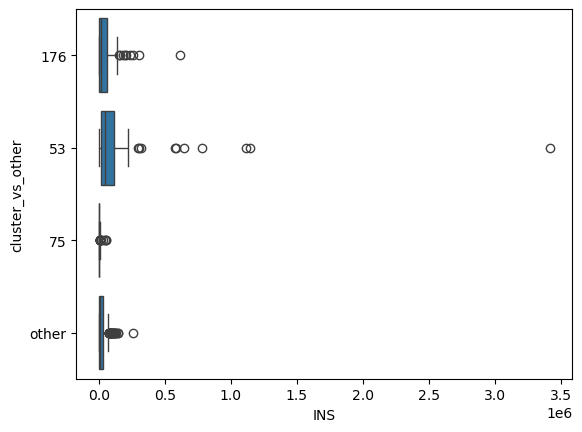

In [36]:
import seaborn as sns
sns.boxplot(data=normalized_counts, x="INS", y="cluster_vs_other")

In [19]:
normalized_counts.loc[normalized_counts['INS'].idxmax()]

DDX11L1                                  0.0
WASH7P                                   0.0
MIR1302-2HG                              0.0
OR4G4P                                   0.0
OR4G11P                                  0.0
                                     ...    
MT-TT                                    0.0
MT-TP                                    0.0
cluster_vs_other                          53
ic_id_platform_adjusted_sample    ic_8_22_16
name                                HPAP_10x
Name: 762, Length: 52911, dtype: object

In [24]:
adata.obs['doublet_probability'][adata.obs['ic_id_platform_adjusted_sample']=='ic_8_22_16'].max()

np.float64(0.6493089)

In [ ]:
adata.obs[adata.obs['cluster_vs_other'] == 'target'][['name', 'platform']].value_counts()

In [ ]:
# Pseudobulk
# aggregated counts
pseudobulk_adata = sc.get.aggregate(adata = adata,
                           by = ['ic_id_platform_adjusted_sample', 'cluster_vs_other'], layer = 'counts', func = 'sum')

In [ ]:
# Extract counts from layers['sum']
counts_df = pd.DataFrame(pseudobulk_adata.layers['sum'], columns=pseudobulk_adata.var_names, index=pseudobulk_adata.obs_names)

# Metadata / covariates
metadata_df = pseudobulk_adata.obs[['cluster_vs_other', 'ic_id_platform_adjusted_sample']].copy()

In [ ]:
# Filter data
# Filter out genes that have less than 10 read counts in total.
genes_to_keep = counts_df.columns[counts_df.sum(axis=0) >= 10]
counts_df = counts_df[genes_to_keep]

In [ ]:
# Create Deseq object
inference = DefaultInference(n_cpus=30)

dds = DeseqDataSet(
    counts=counts_df,
    metadata=metadata_df,
    design="~ ic_id_platform_adjusted_sample + cluster_vs_other", 
    refit_cooks=True,
    inference=inference,
)

In [ ]:
# Fit dispertion and logfoldchanges
dds.deseq2()

In [ ]:
# Statistical test
ds = DeseqStats(
    dds,
    contrast=("cluster_vs_other", "target", "other"), 
    inference = inference)

In [ ]:
# run wald test
ds.run_wald_test()

In [ ]:
import pickle as pkl
with open(os.path.join(tmp_dir, "ds.pkl"), "wb") as f:
    pkl.dump(ds, f)

In [ ]:
res = ds.results_df.copy()
res_filt = res[(res.padj <= 0.05) &(res.log2FoldChange >= 1)]

In [ ]:
!wget https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Mammalia/Homo_sapiens.gene_info.gz

In [ ]:
!gunzip Homo_sapiens.gene_info.gz

In [ ]:
!gunzip Homo_sapiens.gene_info.gz
# Download gene summary text from genes from ncbi (acess: 06-11-2025)
!wget https://ftp.ncbi.nlm.nih.gov/gene/DATA/gene_summary.gz

In [ ]:
gene_summary=gene_summary[gene_summary['#tax_id']=='9606']
genes_to_add = list(gene_summary['GeneID'])

In [ ]:
# load summaries
gene_summary = pd.read_csv( "gene_summary.gz", sep="\t", dtype=str)
homo_gene = pd.read_csv( "Homo_sapiens.gene_info", sep="\t", dtype=str)

# map of ncbi gene id to symbol
homo_gene_map = homo_gene.set_index('GeneID')['Symbol'].to_dict()

# subset gene is to human taxid (9606), and add gene symbols
gene_summary=gene_summary[gene_summary['#tax_id']=='9606']

# Add synbol to gene id
gene_summary['symbol'] = gene_summary['GeneID'].map(homo_gene_map)

In [ ]:
# How to extract normalized counts
normalized_counts=pd.DataFrame(dds.layers['normed_counts'], columns=dds.var_names, index=dds.obs_names)

GO term

In [ ]:
# Define universe
genes =pd.read_csv(here('genome_files/gene_entrez_map.csv'), index_col = 1, dtype='str')
# create dictionary
gene_map = genes['entrez_id'].to_dict()

# add entrez id to index
res['entrez_id'] = res.index.map(gene_map)

# genes upregulated in target
genes_to_test = res[(res.padj <= 0.05) & (res.log2FoldChange >= 1)]['entrez_id'].dropna().tolist()

# https://geneontology.org/docs/download-ontology/

# # Download gene ontology sources:
# !wget https://current.geneontology.org/ontology/go-basic.obo
# !wget https://current.geneontology.org/annotations/goa_human.gaf.gz
# !gunzip goa_human.gaf.gz


from goatools.obo_parser import GODag
from goatools.associations import read_gaf
import pandas as pd
from mygene import MyGeneInfo
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# ------------------------------------------
# Load GO DAG and GAF annotations
# ------------------------------------------
obo = GODag("go-basic.obo")
gaf = read_gaf("goa_human.gaf")   # dict: GO term -> set of gene IDs (Entrez/UniProt depending on source)

# GAF is dict: {uniprot_id: {GO_term1, GO_term2, ...}}
print(f"Loaded {len(gaf)} gene-GO associations")

# ------------------------------------------
# Map UniProt IDs → Entrez IDs
# ------------------------------------------
mg = MyGeneInfo()

# Extract all uniprot genes, that are found in go-terms
uniprot_ids = list(gaf.keys())

# Query mygene.info API to map UniProt → Entrez
mapping = mg.querymany(uniprot_ids, scopes="uniprot", fields="entrezgene", species="human")

# Make a mapping dictionary with uniprot x entrez genes
uni_to_entrez = {m["query"]: str(m["entrezgene"]) for m in mapping if "entrezgene" in m}

# Make a mapping dictionary with eniprot x gene symbols 
mapping = mg.querymany(uniprot_ids, scopes="uniprot", fields="symbol", species="human")
uni_to_symbol = {m["query"]: str(m["symbol"]) for m in mapping if "symbol" in m}

# Filter GAF annotations to those with Entrez mappings
rows = []
for uni, go_terms in gaf.items():
    if uni not in uni_to_entrez:
        continue
    entrez = uni_to_entrez[uni]
    symbol = uni_to_symbol[uni]
    
    for go in go_terms:
        rows.append((entrez, symbol, go))

# Make a dataframe, with go terms, entrez id, and their name
go_df = pd.DataFrame(rows, columns=["entrez", "symbol", "GO_term"])
go_df["GO_name"] = go_df["GO_term"].map(lambda go: obo[go].name if go in obo else None)
go_df["GO_space"] = go_df["GO_term"].map(lambda go: obo[go].namespace if go in obo else None)

print(f"GO annotations available for {go_df['entrez'].nunique()} Entrez genes")

# https://bioinformatics.ccr.cancer.gov/docs/btep-coding-club/CC2023/FunctionalEnrich_clusterProfiler/

# Filter annotations to universe only
go_df = go_df[go_df["entrez"].isin(universe)]
    
universe = set(universe)
genes_to_test = set(genes_to_test)

# Prepare results
results = []
for go_term, group in go_df.groupby("GO_term"):
    genes_in_term = set(group["entrez"])
    a = len(genes_to_test & genes_in_term) # genes in test set and go terms
    b = len(genes_to_test - genes_in_term) # genes in test but not in go terms
    c = len((universe & genes_in_term) - genes_to_test) # background genes that are not in test, that are in go terms
    d = len(universe - genes_in_term - genes_to_test) # background genes that are not in test and not in go terms

    # if non of the test or background genes are found in the go term, skip
    if a + c == 0:
        continue

    odds, p = fisher_exact([[a, b], [c, d]], alternative="greater")

    # Create a list of genes in test set that are in go terms
    genes_in_term = set(group["entrez"])
    overlap = genes_to_test & genes_in_term
    df=group[group["entrez"].isin(overlap)]
    gene_symbols=df['symbol'].tolist()
    
    results.append({
        "go_term": go_term,
        "go_name": obo[go_term].name if go_term in obo else None,
        "gene_id": ','.join(map(str, gene_symbols)),
        "gene_ratio": f'{a}/{len(genes_to_test)}', #ratio of input genes that are annotated in a term
        "gene_ratio_term": f'{a}/{len(genes_in_term)}',
        "bg_ratio": f'{c}/{len(universe)}', # ratio of all genes that are annotated in this term
        "odds_ratio": odds, "pval": p
    })

res_go = pd.DataFrame(results)
res_go["p_adj"] = multipletests(res_go["pval"], method="fdr_bh")[1]
res_go  = res_go.sort_values("p_adj").reset_index(drop=True)

print(res_go.head(10))

In [ ]:
# Get results
res = ds.results_df.copy()

In [ ]:
# Define universe
genes =pd.read_csv(here('genome_files/gene_entrez_map.csv'), index_col = 1, dtype='str')
# create dictionary
gene_map = genes['entrez_id'].to_dict()

In [ ]:
# add entrez id to index
res['entrez_id'] = res.index.map(gene_map)

In [ ]:
# Define universe
universe = res['entrez_id'].dropna().tolist()

In [ ]:
# genes upregulated in target
genes_to_test = res[(res.padj <= 0.05) & (res.log2FoldChange >= 1)]['entrez_id'].dropna().tolist()

In [ ]:
# https://geneontology.org/docs/download-ontology/

# # Download gene ontology sources:
# !wget https://current.geneontology.org/ontology/go-basic.obo
# !wget https://current.geneontology.org/annotations/goa_human.gaf.gz
# !gunzip goa_human.gaf.gz

In [ ]:
from goatools.obo_parser import GODag
from goatools.associations import read_gaf
import pandas as pd
from mygene import MyGeneInfo
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# ------------------------------------------
# Load GO DAG and GAF annotations
# ------------------------------------------
obo = GODag("go-basic.obo")
gaf = read_gaf("goa_human.gaf")   # dict: GO term -> set of gene IDs (Entrez/UniProt depending on source)

# GAF is dict: {uniprot_id: {GO_term1, GO_term2, ...}}
print(f"Loaded {len(gaf)} gene-GO associations")

# ------------------------------------------
# Map UniProt IDs → Entrez IDs
# ------------------------------------------
mg = MyGeneInfo()

# Extract all uniprot genes, that are found in go-terms
uniprot_ids = list(gaf.keys())

# Query mygene.info API to map UniProt → Entrez
mapping = mg.querymany(uniprot_ids, scopes="uniprot", fields="entrezgene", species="human")

# Make a mapping dictionary with uniprot x entrez genes
uni_to_entrez = {m["query"]: str(m["entrezgene"]) for m in mapping if "entrezgene" in m}

# Make a mapping dictionary with eniprot x gene symbols 
mapping = mg.querymany(uniprot_ids, scopes="uniprot", fields="symbol", species="human")
uni_to_symbol = {m["query"]: str(m["symbol"]) for m in mapping if "symbol" in m}

# Filter GAF annotations to those with Entrez mappings
rows = []
for uni, go_terms in gaf.items():
    if uni not in uni_to_entrez:
        continue
    entrez = uni_to_entrez[uni]
    symbol = uni_to_symbol[uni]
    
    for go in go_terms:
        rows.append((entrez, symbol, go))

# Make a dataframe, with go terms, entrez id, and their name
go_df = pd.DataFrame(rows, columns=["entrez", "symbol", "GO_term"])
go_df["GO_name"] = go_df["GO_term"].map(lambda go: obo[go].name if go in obo else None)
go_df["GO_space"] = go_df["GO_term"].map(lambda go: obo[go].namespace if go in obo else None)

print(f"GO annotations available for {go_df['entrez'].nunique()} Entrez genes")

In [ ]:
obo['GO:0006457']

In [ ]:
# maybe only use parent terms?
obo['GO:0006457'].get_all_parents()

In [ ]:
# https://bioinformatics.ccr.cancer.gov/docs/btep-coding-club/CC2023/FunctionalEnrich_clusterProfiler/

# Filter annotations to universe only
go_df = go_df[go_df["entrez"].isin(universe)]
    
universe = set(universe)
genes_to_test = set(genes_to_test)

# Prepare results
results = []
for go_term, group in go_df.groupby("GO_term"):
    genes_in_term = set(group["entrez"])
    a = len(genes_to_test & genes_in_term) # genes in test set and go terms
    b = len(genes_to_test - genes_in_term) # genes in test but not in go terms
    c = len((universe & genes_in_term) - genes_to_test) # background genes that are not in test, that are in go terms
    d = len(universe - genes_in_term - genes_to_test) # background genes that are not in test and not in go terms

    # if non of the test or background genes are found in the go term, skip
    if a + c == 0:
        continue

    odds, p = fisher_exact([[a, b], [c, d]], alternative="greater")

    # Create a list of genes in test set that are in go terms
    genes_in_term = set(group["entrez"])
    overlap = genes_to_test & genes_in_term
    df=group[group["entrez"].isin(overlap)]
    gene_symbols=df['symbol'].tolist()
    
    results.append({
        "go_term": go_term,
        "go_name": obo[go_term].name if go_term in obo else None,
        "gene_id": ','.join(map(str, gene_symbols)),
        "gene_ratio": f'{a}/{len(genes_to_test)}', #ratio of input genes that are annotated in a term
        "gene_ratio_term": f'{a}/{len(genes_in_term)}',
        "bg_ratio": f'{c}/{len(universe)}', # ratio of all genes that are annotated in this term
        "odds_ratio": odds, "pval": p
    })

res_go = pd.DataFrame(results)
res_go["p_adj"] = multipletests(res_go["pval"], method="fdr_bh")[1]
res_go  = res_go.sort_values("p_adj").reset_index(drop=True)

print(res_go.head(10))

In [ ]:
res_go[res_go['p_adj']<= 0.05]

In [ ]:
adata_obs = adata.obs.copy()
adata_obs = adata_obs.join(module_score)
adata_obs = adata_obs.join(
    doublet_probs[["doublet_probability"]],
    how="left")
# save as csv
adata_obs.to_csv(os.path.join(files_dir, 'adata_obs.csv'), index_label='barcode')

In [ ]:
barcodes_keep = pd.read_csv(os.path.join(files_dir, 'barcodes_keep.csv'))
mask = barcodes_keep['barcode']

In [ ]:
subset = adata[mask].copy()
sc.pl.embedding(subset, basis="X_latent_2_umap", color=["leiden_res_10.00", "doublet_probability", "study_cell_annotation_harmonized"], frameon=False, legend_loc = None)

In [ ]:
# Select all categories except 'unknown'
groups_to_plot = [g for g in subset.obs['study_cell_annotation_harmonized'].unique() if g != 'unknown']
subset = adata[mask].copy()
sc.pl.embedding(
    subset, 
    basis="X_latent_2_umap", 
    color=["study_cell_annotation_harmonized"], 
    groups=groups_to_plot, 
    frameon=False, 
    legend_loc=None
)

In [ ]:
# Define clusters to plot
clusters = ["53", "75", "176"]

# Total number of cells (for scaling)
n_cells, _ = adata.shape

# Create a color palette for these clusters
palette = ma.my_color_palette(clusters)

# Loop through each cluster and make a plot
for cluster in clusters:
    # Boolean mask for current cluster
    mask = adata.obs["leiden_res_10.00"] == cluster
    subset = adata[mask].copy()
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(4,4))
    
    # Plot all cells in light gray
    ax.scatter(
        adata.obsm["X_latent_2_umap"][:, 0],
        adata.obsm["X_latent_2_umap"][:, 1],
        c='lightgray', s=120000 / n_cells, 
    )
    
    # Overlay current cluster with its color
    ax.scatter(
        subset.obsm["X_latent_2_umap"][:, 0],
        subset.obsm["X_latent_2_umap"][:, 1],
        facecolors='none',
        edgecolors=palette[cluster],
        s=120000 / n_cells,
    )
    
    # Add title and legend
    ax.set_title(f"Cluster {cluster}")
    ax.set_axis_off()
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Boolean mask for cells in clusters
clusters =  ["53",  "75", "176"]
mask = adata.obs["leiden_res_10.00"].isin(clusters)
subset = adata[mask].copy()

n_cells, _ = adata.shape

# Create figure and axis
fig, ax = plt.subplots(figsize=(5,5))

# Plot all cells in light gray
sc.pl.embedding(
    adata, 
    basis="X_latent_2_umap", 
    color=None, 
    palette=["lightgray"], 
    frameon=False, 
    ax=ax, 
    show=False
)

# Overlay subset with red circles
ax.scatter(
    subset.obsm["X_latent_2_umap"][:, 0],
    subset.obsm["X_latent_2_umap"][:, 1],
    facecolors='none', edgecolors='red', 
    s=1200/n_cells
)

plt.tight_layout()
plt.show()


In [ ]:
# Boolean mask for cells in clusters
clusters = ["139", "145", "148", "166"]
mask = adata.obs["leiden_res_10.00"].isin(clusters)
subset = adata[mask].copy()

n_cells, _ = adata.shape

# Create figure and axis
fig, ax = plt.subplots(figsize=(5,5))

# Plot all cells in light gray
sc.pl.embedding(
    adata, 
    basis="X_latent_2_umap", 
    color=None, 
    palette=["lightgray"], 
    frameon=False, 
    ax=ax, 
    show=False
)

# Overlay subset with red circles
ax.scatter(
    subset.obsm["X_latent_2_umap"][:, 0],
    subset.obsm["X_latent_2_umap"][:, 1],
    facecolors='none', edgecolors='red', linewidths=0.8,
    s=1200/n_cells
)

plt.tight_layout()
plt.show()


In [ ]:
adata.obs.columns

In [ ]:
sc.set_figure_params(figsize=(10, 10), frameon=False, dpi_save= 300)
sc.pl.embedding(
    adata, 
    basis="X_latent_2_umap", 
    color=['NEUROG3'], 
    size = 1,
    frameon=False
)

In [ ]:
sc.set_figure_params(figsize=(10, 10), frameon=False, dpi_save= 300)
sc.pl.embedding(
    adata, 
    basis="X_latent_2_umap", 
    color=['AL590556.3'], 
    cmap=gray_black,
    frameon=False
)

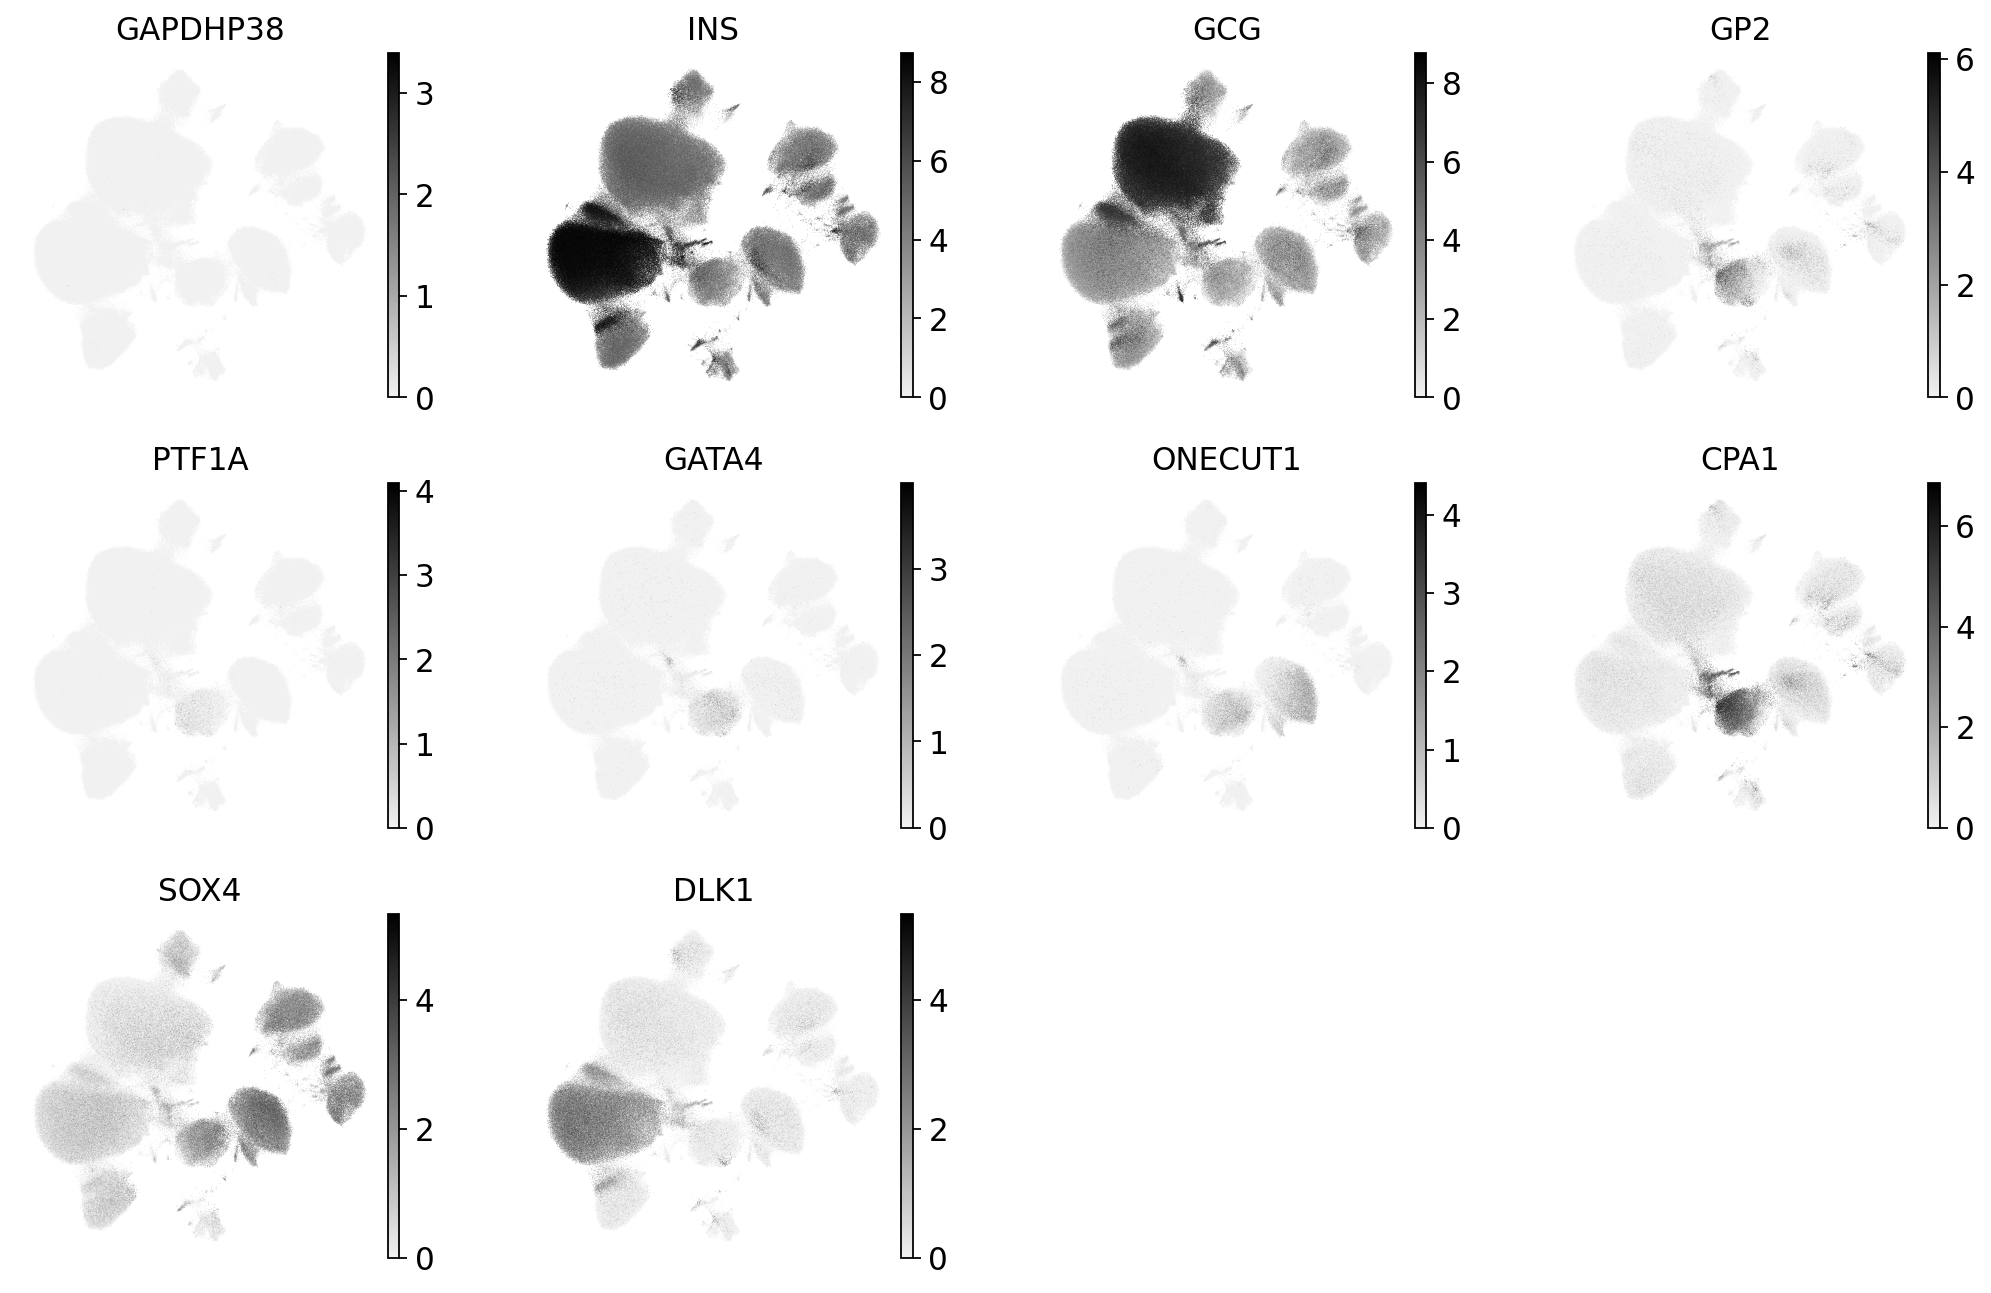

In [37]:
sc.set_figure_params(figsize=(3, 3), frameon=False, dpi_save= 300)

# https://www.biorxiv.org/content/10.1101/2025.10.01.679230v1.supplementary-material
# Multipotent progenitor cells (MPCs) expressed markers
# such as GP2, PTF1A, ONECUT1, and acinar-specific genes
# CPA1, PRSS1, and PRRS2. MPCs have been detected in the
# developing human fetal pancreas expressing CPA1 and GP2
# (8, 68), however, the presence of NEUROG3 in these cells has
# not been previously reported.
    
# Define grey to black color map
gray_black = LinearSegmentedColormap.from_list("gray_black", ["#f1f1f1", "#000000"])

#Neurod1, Nkx2.2, Pax6, and PDX1.
sc.pl.embedding(
    adata, 
    basis="X_latent_2_umap", 
    color=['GAPDHP38', 'INS', 'GCG', 'GP2', 'PTF1A', 'GATA4', 'ONECUT1', 'CPA1', 'SOX4', "DLK1"], 
    cmap=gray_black,
    use_raw=False,
    frameon=False
)

In [ ]:
sc.set_figure_params(figsize=(10,10), frameon=False, dpi_save= 300)

endo_marker = ['INS', 'GCG', 'PPY', 'SST', 'GHRL', 'PDX1']
endo_prog = ['NEUROG3', 'PAX4', 'PAX6']
multi_potent = ['GATA4', 'GP2', 'PTF1A', 'ONECUT1', 'CPA1', 'DLL1', 'YAP1', 'HES1', 'JAG1', 'SOX4', 'DLK1']

sc.pl.dotplot(adata, multi_potent, groupby='cluster_vs_other', use_raw=False)

Get pseudobulk counts, and add platform_adjusted_id

In [ ]:
duct_endo_pro = ['SOX9', 'NKX6-1', 'PDX1']
endo_pro = ['NEUROG3', 'NKX6-1', 'PDX1']
acinar_pro = ['PTF1A', 'GATA4', 'NR5A2']

Differentially expressed genes

In [ ]:
adata.obs['cluster_vs_other'].unique()

In [ ]:
len(adata.obs['ic_id_platform_adjusted_sample'].unique())

In [ ]:
# pseudobulk by samples and cluster
pseudobulk_a = sc.get.aggregate(adata = adata,
                           by = ['ic_id_platform_adjusted_sample', 'cluster_vs_other'], layer = 'counts', func = 'sum')

In [ ]:
counts_df=pd.DataFrame(pseudobulk_a.layers['sum']., index=pseudobulk_a.var_names, columns=pseudobulk_a.obs_names)

In [ ]:
# Differential gene expression

In [ ]:
pd.DataFrame(pseudobulk_a.layers['sum'], columns=pseudobulk_a.var_names, index=pseudobulk_a.obs_names).columns

In [ ]:
import statsmodels.api as sm

In [ ]:
sm.families.NegativeBinomial

In [ ]:
formula = '~ cluster_vs_other + ic_id_platform_adjusted_sample'
library_size = np.ravel(pseudobulk_a.layers['sum'].sum(axis=1))
y = pseudobulk_a.layers['sum'][:, 1].toarray().flatten() if hasattr(pseudobulk_a.layers['sum'], 'toarray') else pseudobulk_a.layers['sum'][:, 1].flatten()
design_df = pseudobulk_a.obs.copy()
design_df['accessibility'] = y
design_df['log_libsize'] = np.log(library_size + 1)

In [ ]:
counts_df = pd.DataFrame(pseudobulk_a.layers['sum'], columns=pseudobulk_a.var_names, index=pseudobulk_a.obs_names)

In [ ]:
to_skip = pseudobulk_a.var_names[counts_df.std() == 0].tolist()

In [ ]:
def fit_regression(pseudobulk_adata):
    import statsmodels.api as sm
    import patsy
    from tqdm import tqdm
    import numpy as np

    # Get library size per sample
    library_size = np.ravel(pseudobulk_adata.layers['sum'].sum(axis=1))
    
    # Formula
    formula = 'expression ~ cluster_vs_other + ic_id_platform_adjusted_sample'
 
    # Store results
    results = []
    
    # Extract counts to dataframe
    counts_df = pd.DataFrame(pseudobulk_adata.layers['sum'], columns=pseudobulk_adata.var_names, index=pseudobulk_adata.obs_names)
    
    # Check gene order is equal in dataframe and var_names
    assert counts_df.columns.tolist() == pseudobulk_adata.var_names.tolist()

    # Skip genes that has a standard variation of 0 across samples
    to_skip = pseudobulk_adata.var_names[counts_df.std() == 0].tolist()
    
    #print(f'skipping: {to_skip}')
 
    # For each peak (feature)
    feats = range(counts_df.shape[1])
    for i in tqdm(feats): # assuming cells x peaks
        if pseudobulk_adata.var_names[i] in to_skip:
            continue
            #print(f'Skipped: {i}')
            # Response: accessibility for peak i across all samples
            y = pseudobulk_adata.layers['sum'][:, i].toarray().flatten() if hasattr(pseudobulk_adata.layers['sum'], 'toarray') else pseudobulk_adata.layers['sum'][:, i].flatten()
 
            # Design matrix
            design_df = pseudobulk_adata.obs.copy()
            design_df['expression'] = y
            design_df['log_libsize'] = np.log(library_size + 1)
 
            # Drop NA if any
            design_df = design_df.dropna()
 
            # Build design matrix using patsy
            y_, X_ = patsy.dmatrices(formula, data=design_df, return_type='dataframe')
            results.append({
                        'gene': pseudobulk_adata.var_names[i],
                        'coef': {x:0 for x in X_.columns}, #res.params.to_dict(),
                        'pval': {x:1 for x in X_.columns}, #res.pvalues.to_dict(),
                        'deviance': 10, #res.deviance,
                        'aic': 0, #res.aic
                    })
        else:
            # Response: accessibility for peak i across all cells
            y = pseudobulk_adata.layers['sum'][:, i].toarray().flatten() if hasattr(pseudobulk_adata.layers['sum'], 'toarray') else pseudobulk_adata.layers['sum'][:, i].flatten()
 
            # Design matrix
            design_df = pseudobulk_adata.obs.copy()
            design_df['expression'] = y
            design_df['log_libsize'] = np.log(library_size + 1)
 
            # Drop NA if any
            design_df = design_df.dropna()
 
            # Build design matrix using patsy
            y_, X_ = patsy.dmatrices(formula, data=design_df, return_type='dataframe')
 
            # Add offset
            offset = design_df.loc[X_.index, 'log_libsize']  # align with design matrix
 
 
            nb_family = sm.families.NegativeBinomial()
            nb_model = sm.GLM(y_, X_, family=nb_family, offset=offset)
            res = nb_model.fit()
 
            # Check keys once (optional: only do this for first iteration)
            if i == 0:
                print("P-value keys:", res.pvalues.index.tolist())
                print("Coefficient keys:", res.params.index.tolist())
 
            results.append({
                        'gene': pseudobulk_adata.var_names[i],
                        'coef': res.params.to_dict(),
                        'pval': res.pvalues.to_dict(),
                        'deviance': res.deviance,
                        'aic': res.aic
                    })
    summary_df = pd.DataFrame([{
        'gene': r['gene'],
        **{f'pval_{k}': v for k, v in r['pval'].items()},
        **{f'coef_{k}': v for k, v in r['coef'].items()},
        'aic': r['aic']
    } for r in results])
 
    return summary_df
 

In [ ]:
def fit_regression(pseudobulk_adata):
    import statsmodels.api as sm
    import patsy
    from tqdm import tqdm
    import numpy as np
    import pandas as pd
    import warnings
    from statsmodels.tools.sm_exceptions import PerfectSeparationWarning
    warnings.simplefilter("ignore", PerfectSeparationWarning)

    library_size = np.ravel(pseudobulk_adata.layers['sum'].sum(axis=1))
    formula = 'expression ~ cluster_vs_other + ic_id_platform_adjusted_sample'
    results = []

    counts_df = pd.DataFrame(
        pseudobulk_adata.layers['sum'],
        columns=pseudobulk_adata.var_names,
        index=pseudobulk_adata.obs_names
    )
    assert counts_df.columns.tolist() == pseudobulk_adata.var_names.tolist()

    to_skip = pseudobulk_adata.var_names[counts_df.std() == 0].tolist()

    for i in tqdm(range(counts_df.shape[1])):
        if pseudobulk_adata.var_names[i] in to_skip:
            continue

        y = (
            pseudobulk_adata.layers['sum'][:, i].toarray().flatten()
            if hasattr(pseudobulk_adata.layers['sum'], 'toarray')
            else pseudobulk_adata.layers['sum'][:, i].flatten()
        )

        design_df = pseudobulk_adata.obs.copy()
        design_df['expression'] = y
        design_df['log_libsize'] = np.log(library_size + 1)
        design_df = design_df.dropna()

        y_, X_ = patsy.dmatrices(formula, data=design_df, return_type='dataframe')
        offset = design_df.loc[X_.index, 'log_libsize']

        nb_family = sm.families.NegativeBinomial(alpha=1.0)
        nb_model = sm.GLM(y_, X_, family=nb_family, offset=offset)
        res = nb_model.fit()

        results.append({
            'gene': pseudobulk_adata.var_names[i],
            'coef': res.params.to_dict(),
            'pval': res.pvalues.to_dict(),
            'deviance': res.deviance,
            'aic': res.aic
        })

    summary_df = pd.DataFrame([{
        'gene': r['gene'],
        **{f'pval_{k}': v for k, v in r['pval'].items()},
        **{f'coef_{k}': v for k, v in r['coef'].items()},
        'aic': r['aic']
    } for r in results])

    return summary_df

In [ ]:
def fit_regression_parallel(pseudobulk_adata, n_jobs=8):
    import statsmodels.api as sm
    import patsy
    import numpy as np
    import pandas as pd
    from tqdm import tqdm
    from joblib import Parallel, delayed
    import warnings
    from statsmodels.tools.sm_exceptions import PerfectSeparationWarning
    from statsmodels.stats.multitest import multipletests

    # Dont show these warnings
    warnings.simplefilter("ignore", PerfectSeparationWarning)
    warnings.filterwarnings("ignore", message="Negative binomial dispersion parameter alpha not set")

    # Compute library size per sample
    libsize = np.ravel(pseudobulk_adata.layers['sum'].sum(axis=1))

    # Define formula for model (y = expression)
    formula = 'expression ~ cluster_vs_other + ic_id_platform_adjusted_sample'

    counts_df = pd.DataFrame(
        pseudobulk_adata.layers['sum'],
        columns=pseudobulk_adata.var_names,
        index=pseudobulk_adata.obs_names
    )

    # check genes are same order
    assert counts_df.columns.tolist() == pseudobulk_adata.var_names.tolist()

    # Skip all-zero or zero-variance genes
    genes_to_fit = pseudobulk_adata.var_names[(counts_df.sum() > 0) & (counts_df.std() > 0)]

    # Fit each gene to a negative bionominal model
    def fit_gene(gene):
        y = (
            pseudobulk_adata.layers['sum'][:, pseudobulk_adata.var_names.get_loc(gene)].toarray().flatten()
            if hasattr(pseudobulk_adata.layers['sum'], 'toarray')
            else pseudobulk_adata.layers['sum'][:, pseudobulk_adata.var_names.get_loc(gene)].flatten()
        )

        # Generate design matrix
        design_df = pseudobulk_adata.obs.copy()
        design_df['expression'] = y
        design_df['log_libsize'] = np.log(libsize + 1)
        design_df = design_df.dropna()

        try:
            # Make a single design matrix given a formula_like and data.
            y_, X_ = patsy.dmatrices(formula, data=design_df, return_type='dataframe')
            offset = design_df.loc[X_.index, 'log_libsize']

            nb_model = sm.GLM(y_, X_, family=sm.families.NegativeBinomial(alpha = 1.0), offset=offset)
            res = nb_model.fit()
        except Exception:
            return {
                'peak': gene,
                'coef_cluster_vs_other': np.nan,
                'pval_cluster_vs_other': np.nan,
                'aic': np.nan
            }

        return {
            'peak': gene,
            'coef_cluster_vs_other': res.params.get('cluster_vs_other[T.target]', np.nan),
            'pval_cluster_vs_other': res.pvalues.get('cluster_vs_other[T.target]', np.nan),
            'aic': res.aic
        }

    # Run in parallel - with progressbar (tqdm)
    # Using the delayed function postpones the function call until parallelism is activated
    # This allows joblib to collect all tasks first and then distribute them to multiple workers efficiently.
    # it says "run this function later"
    results = Parallel(n_jobs=n_jobs, prefer="threads")(
        delayed(fit_gene)(gene) for gene in tqdm(genes_to_fit)
    )

    summary_df = pd.DataFrame(results)
    summary_df['padj_cluster_vs_other'] = multipletests(
        summary_df['pval_cluster_vs_other'].fillna(1), method='fdr_bh'
    )[1]
    return summary_df.sort_values('padj_cluster_vs_other')

In [ ]:
summary_df = fit_regression_parallel(pseudobulk_a, n_jobs = 60)

In [ ]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data

# aggregated counts
pseudobulk_adata = sc.get.aggregate(adata = adata,
                           by = ['ic_id_platform_adjusted_sample', 'cluster_vs_other'], layer = 'counts', func = 'sum')

# Extract counts from layers['sum']
counts_matrix = pseudobulk_adata.layers['sum']
if hasattr(counts_matrix, 'toarray'):  # if sparse
    counts_matrix = counts_matrix.toarray()

counts_df = pd.DataFrame(
    counts_matrix,
    index=pseudobulk_adata.obs_names,  # samples
    columns=pseudobulk_adata.var_names  # genes
)

# Metadata / covariates
metadata_df = pseudobulk_adata.obs[['cluster_vs_other', 'ic_id_platform_adjusted_sample']].copy()


inference = DefaultInference(n_cpus=30)
dds = DeseqDataSet(
    counts=counts_df,
    metadata=metadata_df,
    design="~ ic_id_platform_adjusted_sample + cluster_vs_other", 
    refit_cooks=True,
    inference=inference,
)

# Run DESeq2 workflow
dds.fit_size_factors()
dds.fit_genewise_dispersions()
dds.fit_dispersion_trend()
dds.fit_dispersion_prior()
dds.fit_MAP_dispersions()
dds.fit_LFC()
dds.calculate_cooks()

if dds.refit_cooks:
    # Replace outlier counts
    dds.refit()

ds = DeseqStats(
    dds,
    contrast=("cluster_vs_other", "target", "other"),
    alpha=0.05,
    cooks_filter=True,
    independent_filter=True,
)

ds.run_wald_test()

if ds.cooks_filter:
    ds._cooks_filtering()


if ds.independent_filter:
    ds._independent_filtering()
else:
    ds._p_value_adjustment()

res = ds.results_df.copy()
res_filt = res[(res.padj <= 0.05)]
res_filt .nlargest(20, 'log2FoldChange')

In [ ]:
# If the layer is a sparse matrix, convert it to dense first
counts_matrix = pseudobulk_a.layers['sum']

# Convert to dense if sparse
if hasattr(counts_matrix, "toarray"):
    counts_matrix = counts_matrix.toarray()

# Create a pandas DataFrame
counts_df = pd.DataFrame(
    counts_matrix,
    index=pseudobulk_a.obs.index,   # the aggregated sample x cluster names
    columns=pseudobulk_a.var_names  # gene names
)

counts_df.head()

In [ ]:
meta_df=adata.obs[['ic_id_platform_adjusted_sample', 'ic_id_donor_overall', 'ic_id_dataset', 'cluster_vs_other', 'library_prep']].copy()
meta_df=meta_df.reset_index(drop=True).drop_duplicates()
meta_df['sample_cluster']= meta_df[['ic_id_platform_adjusted_sample', 'cluster_vs_other']].agg('_'.join, axis=1)
meta_df=meta_df.set_index('sample_cluster')
meta_df

In [ ]:
counts_df.transpose().to_csv(os.path.join(tmp_dir, 'counts_df.csv'), index_label='gene_symbol', chunksize=100000)
meta_df.to_csv(os.path.join(tmp_dir, 'meta_df.csv'), index_label='sample_cluster', chunksize=100000)

In [ ]:
myList = adata.var['gene_symbol'].to_list().copy()

In [ ]:
[item for item in myList if item.startswith('NKX')]

In [ ]:
sc.pl.embedding(
    adata, 
    basis="X_latent_2_umap", 
    color='AC107954.1', 
    cmap="coolwarm",
    frameon=False
)

In [ ]:
# Boolean mask for cells in clusters
#clusters = ["40", "71", "95", "98", "99", "100", "114", "129", "137", "138", "139", "143", "145", "147", "148", "156", "158", "166", "181", "187"]
clusters = ["14", "18", "22", "25", "30", "40", "47", "62", "67", "71", "88", "92", "95", "98", "99", "100", "101", "108", "112", "114", "115", "122", "129", "131", "137", "138", "139", "143", "144", "145", "147", "148", "156", "158", "166", "181", "186", "187"]

mask = (adata.obs["leiden_res_10.00"].isin(clusters) |
        (adata.obs["doublet_probability"] >= 0.9))

subset = adata[mask]

n_cells, _ = adata.shape

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Base embedding
sc.pl.embedding(adata, basis="X_latent_2_umap", color=None, palette=["lightgray"],
                ax=axes[0], show=False, frameon=False)
axes[0].scatter(subset.obsm["X_latent_2_umap"][:, 0],
                subset.obsm["X_latent_2_umap"][:, 1],
                facecolors='none', edgecolors='red', linewidths=0.8,
                s=1200/n_cells)
axes[0].set_title("Doublet cells", fontsize=10)

# Doublet probability
sc.pl.embedding(adata, basis="X_latent_2_umap", color="doublet_probability",
                ax=axes[1], show=False, frameon=False)
axes[1].set_title("Doublet probability", fontsize=10)

# Clustering
# Doublet probability
sc.pl.embedding(adata, basis="X_latent_2_umap", color="leiden_res_10.00",
                ax=axes[2], show=False, frameon=False, legend_loc = 'on data')
axes[2].set_title("Leiden res 10.00", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Boolean mask for cells in clusters
clusters = ["40", "71", "95", "98", "99", "100", "114", "129", "137", "138", "139", "143", "145", "147", "148", "156", "158", "166", "181", "187"]
mask = (adata.obs["leiden_res_10.00"].isin(clusters) |
        (adata.obs["doublet_probability"] >= 0.9))
subset = adata[mask]

n_cells, _ = adata.shape

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

# Base embedding
sc.pl.embedding(adata, basis="X_latent_2_umap", color=None, palette=["lightgray"],
                ax=axes[0], show=False, frameon=False)
axes[0].scatter(subset.obsm["X_latent_2_umap"][:, 0],
                subset.obsm["X_latent_2_umap"][:, 1],
                facecolors='none', edgecolors='red', linewidths=0.8,
                s=1200/n_cells)
axes[0].set_title("Clusters with median doublet probability >= 50%", fontsize=10)

# Doublet probability
sc.pl.embedding(adata, basis="X_latent_2_umap", color="doublet_probability",
                ax=axes[1], show=False, frameon=False)
axes[1].set_title("Doublet probability", fontsize=10)

# nUMI
sc.pl.embedding(adata, basis="X_latent_2_umap", color="n_umi",
                ax=axes[2], show=False, frameon=False)
axes[2].set_title("UMI count", fontsize=10)
# n_count
sc.pl.embedding(adata, basis="X_latent_2_umap", color="n_count",
                ax=axes[3], show=False, frameon=False)
axes[3].set_title("Read count", fontsize=10)

# n_feature
sc.pl.embedding(adata, basis="X_latent_2_umap", color="n_feature",
                ax=axes[4], show=False, frameon=False)
axes[4].set_title("Feature count", fontsize=10)


plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
# Boolean mask for cells with doublet probability >= 0.9
mask = adata.obs["doublet_probability"] >= 0.9
subset = adata[mask]

n_cells, _ = adata.shape

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

# Base embedding
sc.pl.embedding(adata, basis="X_latent_2_umap", color=None, palette=["lightgray"],
                ax=axes[0], show=False, frameon=False)
axes[0].scatter(subset.obsm["X_latent_2_umap"][:, 0],
                subset.obsm["X_latent_2_umap"][:, 1],
                facecolors='none', edgecolors='red', linewidths=0.8,
                s=1200/n_cells)
axes[0].set_title("Cells with doublet probability > 0.9", fontsize=10)

# Doublet probability
sc.pl.embedding(adata, basis="X_latent_2_umap", color="doublet_probability",
                ax=axes[1], show=False, frameon=False)
axes[1].set_title("Doublet probability", fontsize=10)

# nUMI
sc.pl.embedding(adata, basis="X_latent_2_umap", color="n_umi",
                ax=axes[2], show=False, frameon=False)
axes[2].set_title("UMI count", fontsize=10)
# n_count
sc.pl.embedding(adata, basis="X_latent_2_umap", color="n_count",
                ax=axes[3], show=False, frameon=False)
axes[3].set_title("Read count", fontsize=10)

# n_feature
sc.pl.embedding(adata, basis="X_latent_2_umap", color="n_feature",
                ax=axes[4], show=False, frameon=False)
axes[4].set_title("Feature count", fontsize=10)


plt.tight_layout()
plt.show()